# Grupo 3 — Random Forest (Poluição)

Primeira aplicação do Random Forest à base tratada do grupo 3. Horizonte: **um horário passo à frente**. Todas as métricas e figuras ficam neste notebook. Os parâmetros abaixo são uma configuração inicial comum, **ainda não otimizados para esta base** (T11 pendente).

In [1]:
from pathlib import Path
import os
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from preparacao_bases import carregar_base_tratada
from features_temporais import preparar_features_base
from funcoes_series_temporais import calcular_importancia_features

## T01 — Base tratada e protocolo

O Excel comum fornece o alvo, a frequência, a seed e o instante fixo de início do teste. O modelo não modifica a base tratada.

In [2]:
BASE_NAME = 'poluicao'
GRUPO = 3
UNIDADE = 'PM2.5 (µg/m³)'
df, meta = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
assert meta['grupo'] == GRUPO and meta['frequencia'] == 'h'
SEED = meta['seed']
INICIO_TESTE = pd.Timestamp(meta['inicio_teste'])
print(f"Base: {BASE_NAME} | alvo: {meta['alvo']} | frequência: {meta['frequencia']}")
print(f"Seed: {SEED} | treino/teste: {meta['treino']:.0%}/{1-meta['treino']:.0%} | início do teste: {INICIO_TESTE}")
print(f"Grade: {len(df):,} períodos | alvo observado: {df[meta['alvo']].notna().sum():,}")

Base: poluicao | alvo: PM2.5 | frequência: h
Seed: 42 | treino/teste: 80%/20% | início do teste: 2016-05-12 19:00:00
Grade: 35,064 períodos | alvo observado: 34,139


## T06 — Features temporais compartilhadas

Lags do alvo e das exógenas, médias móveis e calendário são calculados na grade inteira antes de eliminar linhas com ausências. Todas as medidas do período previsto entram apenas por defasagem.

In [3]:
grade_features = preparar_features_base(
    df, BASE_NAME, meta['alvo'], meta['frequencia'], remover_incompletos=False
)
model_data = grade_features.dropna()
treino = model_data.loc[model_data.index < INICIO_TESTE]
teste = model_data.loc[model_data.index >= INICIO_TESTE]
if treino.empty or teste.empty or treino.index.max() >= teste.index.min():
    raise ValueError('Treino/teste temporal inválido ou sem linhas completas.')
X_train, y_train = treino.drop(columns='target'), treino['target']
X_test, y_test = teste.drop(columns='target'), teste['target']
observados_teste = int(df.loc[df.index >= INICIO_TESTE, meta['alvo']].notna().sum())
cobertura = pd.DataFrame([{
    'features': X_train.shape[1], 'treino_elegivel': len(treino),
    'teste_grade': meta['linhas_teste'], 'teste_alvo_observado': observados_teste,
    'teste_elegivel': len(teste),
    'cobertura_grade_%': 100 * len(teste) / meta['linhas_teste'],
    'cobertura_alvos_observados_%': 100 * len(teste) / observados_teste,
}])
display(cobertura.round(2))
print('Todas as linhas avaliadas têm alvo e features observados; períodos excluídos não entram no MAE.')

# Diagnóstico de mudança de faixa do alvo; usado só para interpretar o teste.
alvo_treino = df.loc[df.index < INICIO_TESTE, meta['alvo']].dropna()
alvo_teste = df.loc[df.index >= INICIO_TESTE, meta['alvo']].dropna()
faixa_alvo = pd.DataFrame([{
    'min_treino': alvo_treino.min(), 'max_treino': alvo_treino.max(),
    'min_teste': alvo_teste.min(), 'max_teste': alvo_teste.max(),
    'teste_acima_max_treino_%': 100 * alvo_teste.gt(alvo_treino.max()).mean(),
}])
display(faixa_alvo.round(2))


,features,treino_elegivel,teste_grade,teste_alvo_observado,teste_elegivel,cobertura_grade_%,cobertura_alvos_observados_%
0,40,11752,7013,6906,3023,43.11,43.77


Todas as linhas avaliadas têm alvo e features observados; períodos excluídos não entram no MAE.


,min_treino,max_treino,min_teste,max_teste,teste_acima_max_treino_%
0,3.0,898.0,3.0,713.0,0.0


## T12 — Primeira execução do Random Forest

Configuração inicial definida antes de consultar o teste: 120 árvores, profundidade máxima 16 e mínimo de 2 amostras por folha. Ajuste único no treino; no teste, cada previsão usa o histórico disponível antes do período previsto. Ainda falta a busca de hiperparâmetros por janelas de validação (T11) e a decisão coletiva sobre reajuste em cada origem (T08).

In [4]:
PARAMETROS_INICIAIS = {
    'n_estimators': 120, 'max_depth': 16,
    'min_samples_split': 2, 'min_samples_leaf': 2,
    'max_features': 1.0,
}
modelo = RandomForestRegressor(
    **PARAMETROS_INICIAIS, random_state=SEED, n_jobs=min(4, os.cpu_count() or 1)
)
inicio = time.perf_counter()
modelo.fit(X_train, y_train)
previsto = modelo.predict(X_test)
tempo_ajuste = time.perf_counter() - inicio
previsoes = pd.DataFrame({
    'real': y_test.to_numpy(), 'random_forest': previsto,
    'persistencia': X_test['target_lag_1'].to_numpy(),
}, index=X_test.index)
previsoes.index.name = 'data'
previsoes['residuo'] = previsoes['real'] - previsoes['random_forest']
print(f"Ajuste e previsão: {tempo_ajuste:.1f} s | previsões: {len(previsoes):,}")

Ajuste e previsão: 8.9 s | previsões: 3,023


## T16 — Métricas preliminares

RF e persistência são comparados nos **mesmos timestamps elegíveis**. O teste completo só será comparável aos demais modelos se eles adotarem essa mesma avaliação. O ranking dos 20 pipelines permanece pendente.

In [5]:
def resumir(nome, real, predito):
    erro = real - predito
    return {
        'modelo': nome, 'n': len(real),
        'MAE': mean_absolute_error(real, predito),
        'RMSE': np.sqrt(mean_squared_error(real, predito)),
        'R2': r2_score(real, predito),
        'desvio_residual': np.std(erro, ddof=1),
        'vies_real_menos_previsto': np.mean(erro),
    }
metricas = pd.DataFrame([
    resumir('Random Forest', previsoes['real'], previsoes['random_forest']),
    resumir('Persistência', previsoes['real'], previsoes['persistencia']),
])
mae_rf = float(metricas.loc[metricas.modelo == 'Random Forest', 'MAE'].iloc[0])
mae_persistencia = float(metricas.loc[metricas.modelo == 'Persistência', 'MAE'].iloc[0])
metricas['ganho_MAE_vs_persistencia_%'] = 100 * (1 - metricas['MAE'] / mae_persistencia)
display(metricas.round(4))
print(f'MAE RF: {mae_rf:.4f} | MAE persistência: {mae_persistencia:.4f} | unidade: {UNIDADE}')
if mae_rf >= mae_persistencia:
    print('Nesta configuração inicial, o RF não superou a persistência. A próxima mudança deve ser escolhida na validação do treino.')
else:
    print('Nesta configuração inicial, o RF superou a persistência nos períodos elegíveis.')


,modelo,n,MAE,RMSE,R2,desvio_residual,vies_real_menos_previsto,ganho_MAE_vs_persistencia_%
0,Random Forest,3023,10.2742,17.9371,0.9572,17.9224,0.7946,-1.7862
1,Persistência,3023,10.0939,18.2167,0.9558,18.2194,-0.1085,0.0000


MAE RF: 10.2742 | MAE persistência: 10.0939 | unidade: PM2.5 (µg/m³)
Nesta configuração inicial, o RF não superou a persistência. A próxima mudança deve ser escolhida na validação do treino.


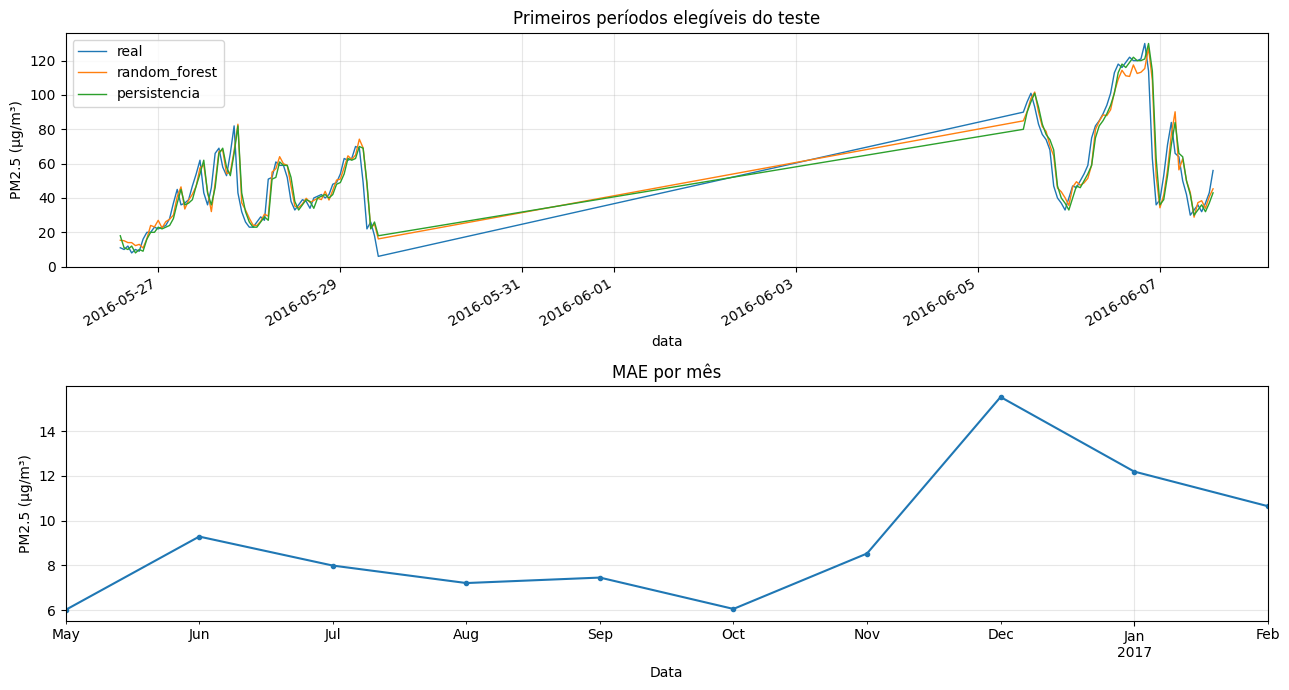

O MAE global acima usa todos os períodos elegíveis, não apenas os mostrados no gráfico superior.


In [6]:
janela = previsoes.iloc[:min(120, len(previsoes))]
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
janela[['real', 'random_forest', 'persistencia']].plot(ax=axes[0], linewidth=1)
axes[0].set(title='Primeiros períodos elegíveis do teste', ylabel=UNIDADE)
periodo_mae = 'MS' if meta['frequencia'] in ('D', 'h') else 'YS'
mae_periodo = previsoes['residuo'].abs().resample(periodo_mae).agg(['mean', 'count'])
mae_periodo.columns = ['MAE', 'n']
mae_periodo.loc[mae_periodo['n'] > 0, 'MAE'].plot(ax=axes[1], marker='o', markersize=3)
axes[1].set(title='MAE por mês' if periodo_mae == 'MS' else 'MAE por ano', ylabel=UNIDADE, xlabel='Data')
for ax in axes: ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('O MAE global acima usa todos os períodos elegíveis, não apenas os mostrados no gráfico superior.')

## T18 — Importância preliminar das features

Permutação no teste, com amostra fixa de até 500 períodos. O desvio representa a variação entre três permutações. Esta análise é interpretativa; a seleção de atributos ainda deve ocorrer somente na validação do treino.

,feature,importancia,desvio_importancia
0,target_lag_1,76.6953,2.5046
1,target_lag_2,3.4787,0.3856
2,PM10_lag_1,2.0143,0.2239
3,NO2_lag_1,1.2628,0.0117
4,target_roll_mean_6,0.8008,0.3245
5,WSPM_lag_1,0.5640,0.1657
6,NO2_lag_24,0.3180,0.0564
7,target_roll_std_168,0.1851,0.0784
8,TEMP_lag_1,0.1370,0.0810
9,PRES_lag_24,0.0807,0.0227


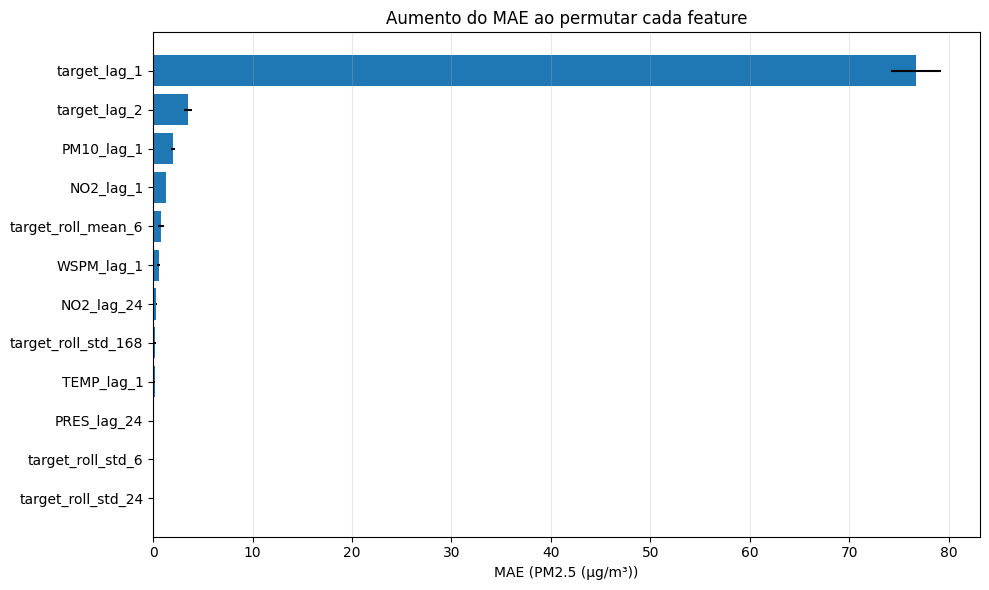

In [7]:
importancias = calcular_importancia_features(
    modelo, X_test, y_test, metodo='permutacao',
    n_repeticoes=3, seed=SEED, n_jobs=1, max_amostras=500,
)
display(importancias[['feature', 'importancia', 'desvio_importancia']].head(12).round(4))
top = importancias.head(12).sort_values('importancia')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['feature'], top['importancia'], xerr=top['desvio_importancia'])
ax.set(title='Aumento do MAE ao permutar cada feature', xlabel=f'MAE ({UNIDADE})')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

### Próximos passos

Esta é uma **referência inicial**, não o resultado final da T11/T12. Comparar configurações por validação temporal dentro do treino; congelar a melhor antes de repetir a avaliação final. Definir T08 com a equipe e depois consolidar os MAEs comparáveis na T16.